Codes to Question 1_5

implement a standard particle filer. discuss the particle degeneracy.

create dataset

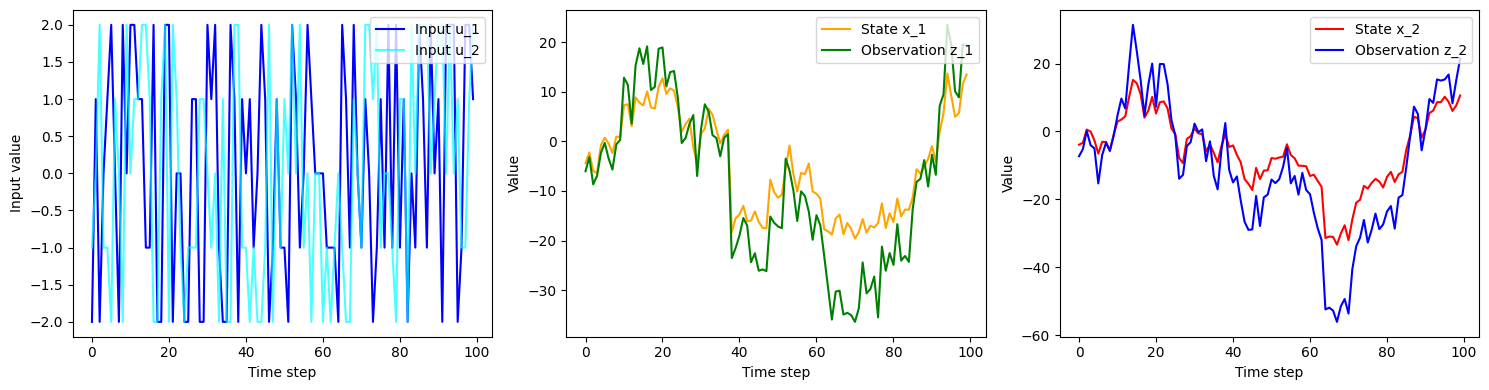

In [8]:
import numpy as np
import matplotlib.pyplot as plt
# random seed
np.random.seed(26)

#  Set sequence length
size = 100
# Dimensions
state_dim = 2
input_dim = 2
obs_dim = 2

# Initial state
x0 = np.array([0.5, -0.3])

uk = np.random.choice(np.arange(-2, 3), size=(size, input_dim)) # Random inputs
xk = np.zeros((size, state_dim)) # hidden states
zk = np.zeros((size, obs_dim)) # observations

# System matrices
A = np.array([[0.85, 0.1],
              [0.05, 0.9]])
B = np.array([[1.5, 0.2],
              [0.1, 1.8]])
C = np.array([[1.2, 0.4],
              [0.3, 1.5]])
D = np.array([[0.5, -0.3],
              [-0.2, 0.7]])

# Covariance matrices for process and measurement noise
Q = np.diag([2.0, 1.5])
R = np.diag([3.0, 2.5])


process_noises = []
measurement_noises = []

for i, u in enumerate(uk):
    # Non-Gaussian process noise: Student's t-distribution (heavy tails)
    # df=3 gives heavy tails, scale to match Q covariance
    process_noise = np.random.standard_t(df=3, size=state_dim) * np.sqrt(np.diag(Q))
    
    process_noises.append(process_noise)
    
    # Nonlinear state transition: bounded nonlinear function (sin)
    if i == 0:
        xk[i] = A @ x0 + B @ u + 0.5 * np.sin(x0) + process_noise
    else:
        xk[i] = A @ xk[i - 1] + B @ u + 0.5 * np.sin(xk[i - 1]) + process_noise

    # Non-Gaussian measurement noise: Student's t-distribution (heavy tails)
    measurement_noise = np.random.standard_t(df=3, size=obs_dim) * np.sqrt(np.diag(R))
    
    measurement_noises.append(measurement_noise)
    
    # Nonlinear observation model: bounded nonlinear function (sin)
    zk[i] = C @ xk[i] + D @ u + 0.3 * np.sin(xk[i]) + measurement_noise

process_noises = np.vstack(process_noises)       # (size, 2)
measurement_noises = np.vstack(measurement_noises)  # (size, 2)


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(uk[:, 0], label='Input u_1', color='blue')
plt.plot(uk[:, 1], label='Input u_2', color='cyan', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Input value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 2)
plt.plot(xk[:, 0], label='State x_1', color='orange')
plt.plot(zk[:, 0], label='Observation z_1', color='green')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 3)
plt.plot(xk[:, 1], label='State x_2', color='red')
plt.plot(zk[:, 1], label='Observation z_2', color='blue')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [9]:
# conditon number calculation via SVD
def svd_and_cond(A: np.ndarray):
    Aw = A.astype(np.float32, copy=False) if A.dtype == np.float16 else A
    S = np.linalg.svd(Aw, compute_uv=False)

    sigma_max = np.max(S)
    sigma_min = np.min(S)
    cond_manual = sigma_max / sigma_min
    return cond_manual

def eigvalsh_safe(SigmaX: np.ndarray):
    compute_dtype = np.float32 if SigmaX.dtype == np.float16 else SigmaX.dtype
    SigmaXw = SigmaX.astype(compute_dtype, copy=False)

    eigvals = np.linalg.eigvalsh(SigmaXw)
    eigvals_out = eigvals
    # eigvals_out = eigvals.astype(np.float16) if SigmaX.dtype == np.float16 else eigvals

    return eigvals_out

def inv_safe(S: np.ndarray):
    compute_dtype = np.float32 if S.dtype == np.float16 else S.dtype
    Sw = S.astype(compute_dtype, copy=False)
    inv_S = np.linalg.inv(Sw)
    inv_S_out = inv_S
    # inv_S_out = inv_S.astype(np.float16) if S.dtype == np.float16 else inv_S
    return inv_S_out

sequential importance sampling (SIS) implementation


In [10]:
import numpy as np
import time
import tracemalloc

# SIS (Particle Filter)
nIter = size
nPart = 500

# initial model guess
params = {}
params["A"] = np.array([[0.75, 0.05],
                    [0.02, 0.8]])  
params["B"] = np.array([[1.2, 0.1],
                    [0.05, 1.4]])
params["C"] = np.array([[1.0, 0.3],
                    [0.2, 1.2]])
params["D"] = np.array([[0.4, -0.2],
                    [-0.1, 0.5]])

params["Q"] = np.diag([3.5, 2.5])   # sigma W (guess)
params["R"] = np.diag([4.5, 3.5])   # sigma V (guess)

k_process = 0.25   # guess
k_measure = 0.85   # guess

# precision setting
dtype = np.float64  # np.float64 (15～17 digits), np.float32 (6~8 digits)， np.float16 (3~4 digits)
for k in ["A", "B", "C", "D", "Q", "R"]:
    params[k] = params[k].astype(dtype)
uk = uk.astype(dtype)
zk = zk.astype(dtype)

time_idx = np.arange(size)
# set random-number-generator state
np.random.seed(26)

# Start memory tracking
tracemalloc.start()
start_time = time.time()

# # Initialize particle values and weights
xp = np.zeros((nPart, nIter, state_dim), dtype=dtype)  # particles over time (each is R^{state_dim})
wp = np.zeros((nPart, nIter), dtype=dtype)            # weights over time

xhatstore_pf = np.zeros((nIter, state_dim), dtype=dtype)
boundstore_pf = np.zeros((nIter, state_dim), dtype=dtype)  # 3-sigma bounds per dimension from particle cov

# Initialize particles around x0 with initial covariance
xhat = np.zeros(state_dim, dtype=dtype)
SigmaX = np.eye(state_dim, dtype=dtype)
xp[:, 0, :] = xhat + np.random.multivariate_normal(mean=np.zeros(state_dim), cov=SigmaX, size=nPart)
wp[:, 0] = 1.0 / nPart

# Initial mean and covariance from particles
xhat0 = np.average(xp[:, 0, :], axis=0, weights=wp[:, 0])
diff0 = xp[:, 0, :] - xhat0[None, :]
cov0 = (diff0 * wp[:, 0][:, None]).T @ diff0  # weighted covariance
xhatstore_pf[0] = xhat0
boundstore_pf[0] = 3.0 * np.sqrt(np.clip(np.diag(cov0), a_min=0.0, a_max=None))

# Gaussian PDF helper: f(z | mu, Sigma) for multidimensional case
def gaussian_pdf(z, mu, Sigma):
    d = z - mu
    inv_Sigma = inv_safe(Sigma)
    sign, logdet = np.linalg.slogdet(Sigma)
    norm_const = 1.0 / np.sqrt((2.0 * np.pi) ** obs_dim * np.exp(logdet))
    return norm_const * np.exp(-0.5 * (d.T @ inv_Sigma @ d))

# Implement SIS for the rest of the trajectory
for k in range(1, nIter):
    for cp in range(nPart):
        # Draw new particle from q(x{k}|x{k-1}, z{k}) = f(x{k}|x{k-1})
        x_prev = xp[cp, k - 1, :]
        process_noise = np.random.multivariate_normal(mean=np.zeros(state_dim), cov=params["Q"])
        xp[cp, k, :] = params["A"] @ x_prev + params["B"] @ uk[k - 1] + k_process * np.sin(x_prev) + process_noise
        
        # Compute the expected value of the measurement given x{k}
        zpred = params["C"] @ xp[cp, k, :] + params["D"] @ uk[k] + k_measure * np.sin(xp[cp, k, :])
        
        # Compute f(z{k}|x{k})
        likelihood = gaussian_pdf(zk[k], zpred, params["R"])
        
        # Compute unnormalized weight: wp_tilde = f(z{k}|x{k}) * wp(cp, k-1)
        wp[cp, k] = wp[cp, k - 1] * likelihood
    
    # Normalize weights
    wsum = np.sum(wp[:, k])
    if wsum == 0:
        # Avoid division-by-zero: fall back to uniform weights (rare under normal conditions)
        wp[:, k] = 1.0 / nPart
    else:
        wp[:, k] = wp[:, k] / wsum

    # Compute PF mean and bounds at time k
    xhat_k = np.sum(wp[:, k][:, None] * xp[:, k, :], axis=0)
    diff = xp[:, k, :] - xhat_k[None, :]
    cov_k = (diff * wp[:, k][:, None]).T @ diff
    xhatstore_pf[k] = xhat_k
    boundstore_pf[k] = 3.0 * np.sqrt(np.clip(np.diag(cov_k), a_min=0.0, a_max=None))

    if k % 10 == 0:
        print(f"Completed iteration {k} out of {nIter}")

# Stop timing and memory tracking
end_time = time.time()
current_memory, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

# Report performance metrics
runtime = end_time - start_time
print("Done!")
print(f"\n{'='*50}")
print(f"Performance Metrics:")
print(f"{'='*50}")
print(f"Runtime:        {runtime:.4f} seconds ({runtime*1000:.2f} ms)")
print(f"Peak Memory:    {peak_memory / 1024**2:.2f} MB")
print(f"Current Memory: {current_memory / 1024**2:.2f} MB")
print(f"{'='*50}")

Completed iteration 10 out of 100
Completed iteration 20 out of 100
Completed iteration 20 out of 100
Completed iteration 30 out of 100
Completed iteration 30 out of 100
Completed iteration 40 out of 100
Completed iteration 40 out of 100
Completed iteration 50 out of 100
Completed iteration 50 out of 100
Completed iteration 60 out of 100
Completed iteration 60 out of 100
Completed iteration 70 out of 100
Completed iteration 70 out of 100
Completed iteration 80 out of 100
Completed iteration 80 out of 100
Completed iteration 90 out of 100
Completed iteration 90 out of 100
Done!

Performance Metrics:
Runtime:        12.6329 seconds (12632.91 ms)
Peak Memory:    1.22 MB
Current Memory: 1.19 MB
Done!

Performance Metrics:
Runtime:        12.6329 seconds (12632.91 ms)
Peak Memory:    1.22 MB
Current Memory: 1.19 MB


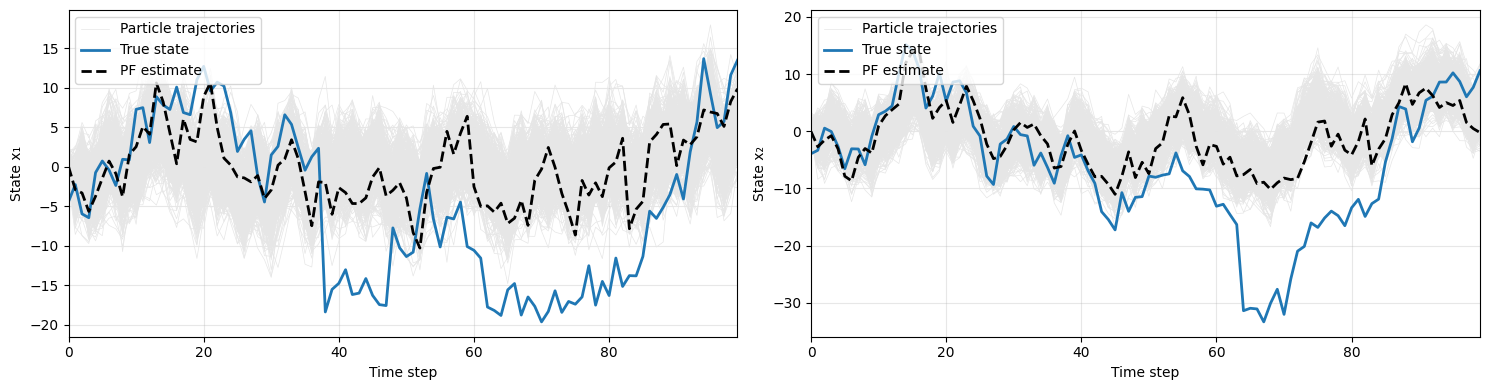

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Plot particle trajectories comparison for x_1
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# x_1 trajectories
h1 = axs[0].plot(time_idx, xp[:, :, 0].T, color=(0.9, 0.9, 0.9), linewidth=0.5)
h2 = axs[0].plot(time_idx, xk[:, 0], color='C0', linewidth=2)[0]
h3 = axs[0].plot(time_idx, xhatstore_pf[:, 0], 'k--', linewidth=2)[0]
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('State x₁')
# axs[0].set_title('Comparing particle trajectories with truth (x₁)')
axs[0].set_xlim(0, nIter - 1)
axs[0].grid(True, alpha=0.3)
axs[0].legend([h1[0], h2, h3], ['Particle trajectories', 'True state', 'PF estimate'], loc='upper left')

# x_2 trajectories
h4 = axs[1].plot(time_idx, xp[:, :, 1].T, color=(0.9, 0.9, 0.9), linewidth=0.5)
h5 = axs[1].plot(time_idx, xk[:, 1], color='C0', linewidth=2)[0]
h6 = axs[1].plot(time_idx, xhatstore_pf[:, 1], 'k--', linewidth=2)[0]
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('State x₂')
# axs[1].set_title('Comparing particle trajectories with truth (x₂)')
axs[1].set_xlim(0, nIter - 1)
axs[1].grid(True, alpha=0.3)
axs[1].legend([h4[0], h5, h6], ['Particle trajectories', 'True state', 'PF estimate'], loc='upper left')

plt.tight_layout()
plt.show()

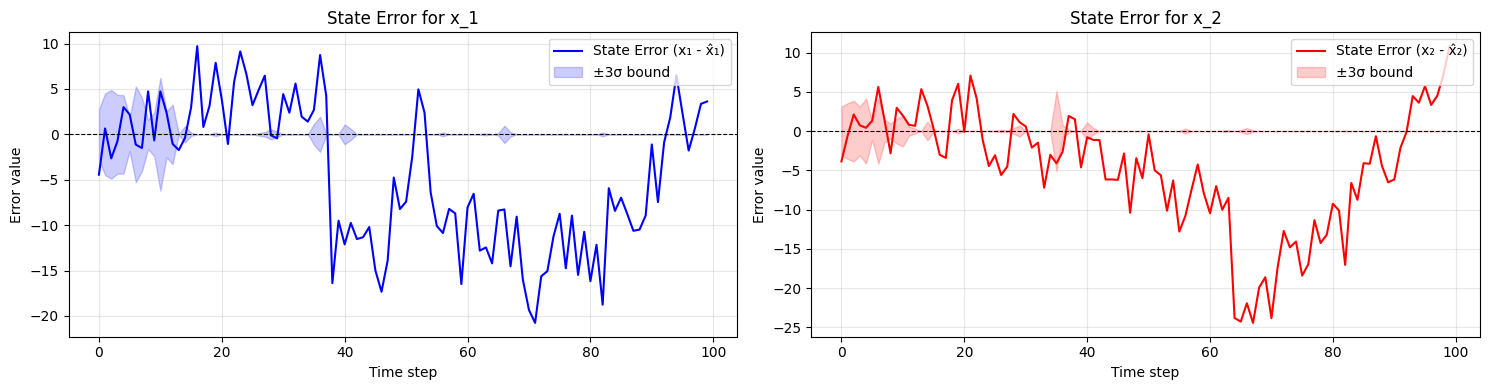

PF: Percentage of x_1 errors within ±3σ bounds: 12.0%
PF: Percentage of x_2 errors within ±3σ bounds: 7.0%


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# PF state error with PF bounds (match KF plotting style)
xerrPF = xk - xhatstore_pf

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrPF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore_pf[:, 0],
                    boundstore_pf[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrPF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore_pf[:, 1],
                    boundstore_pf[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Percentage within bounds
within_bounds_pf_x1 = np.sum(np.abs(xerrPF[:, 0]) <= boundstore_pf[:, 0]) / nIter * 100
within_bounds_pf_x2 = np.sum(np.abs(xerrPF[:, 1]) <= boundstore_pf[:, 1]) / nIter * 100
print(f"PF: Percentage of x_1 errors within ±3σ bounds: {within_bounds_pf_x1:.1f}%")
print(f"PF: Percentage of x_2 errors within ±3σ bounds: {within_bounds_pf_x2:.1f}%")

In [7]:
import numpy as np

print("\nParticle-filter (SIS) results:")
rmse_x1 = np.sqrt(np.mean((xk[:, 0] - xhatstore_pf[:, 0]) ** 2))
rmse_x2 = np.sqrt(np.mean((xk[:, 1] - xhatstore_pf[:, 1]) ** 2))
print(f"RMSE (x_1) = {rmse_x1:5.3f}")
print(f"RMSE (x_2) = {rmse_x2:5.3f}")


Particle-filter (SIS) results:
RMSE (x_1) = 9.007
RMSE (x_2) = 9.093


we saw that many of the particle trajectories are quite different from the true state trajectory.

the particle degeneracy? 


the particle filter started off trakcing well. however, the performance rapidly deteriorated (especailly performance of the condidence bounds).

In [8]:
import numpy as np

# Estimate marginal PDFs over time using weighted bump kernel
nR = 500  # number of grid points
bumpWid = 0.1  # kernel width

# Grid for x_1 based on data range
x1_min = np.min(xk[:, 0])
x1_max = np.max(xk[:, 0])
xGrid = np.linspace(x1_min, x1_max, nR)
width = np.mean(np.diff(xGrid))

# Grid for x_2 based on data range
x2_min = np.min(xk[:, 1])
x2_max = np.max(xk[:, 1])
xGrid2 = np.linspace(x2_min, x2_max, nR)
width2 = np.mean(np.diff(xGrid2))

estPDF_x1 = np.zeros((nR, nIter), dtype=dtype)  # estimate of f(x_1{k}|Z{k})
xLowBndPart_x1 = np.zeros(nIter, dtype=dtype)   # Lower 2.5% bound
xHiBndPart_x1 = np.zeros(nIter, dtype=dtype)    # Upper 97.5% bound

estPDF_x2 = np.zeros((nR, nIter), dtype=dtype)  # estimate of f(x_2{k}|Z{k})
xLowBndPart_x2 = np.zeros(nIter, dtype=dtype)   # Lower 2.5% bound
xHiBndPart_x2 = np.zeros(nIter, dtype=dtype)    # Upper 97.5% bound

# Bump kernel function: (1 - x^2)^2 for |x|<=1, else 0
def kernelFN(x):
    out = (1 - x**2)**2
    out[np.abs(x) > 1] = 0.0
    return out

for k in range(nIter):
    # ---- x_1 ----
    xp1 = xp[:, k, 0]
    iSort1 = np.argsort(xp1)
    xps1 = xp1[iSort1]
    wps1 = wp[iSort1, k]

    # Cumulative sum of sorted weights
    wSum1 = np.cumsum(wps1)

    # Lower 2.5% bound
    if wSum1[0] > 0.025:
        xLowBndPart_x1[k] = xps1[0]
    else:
        idx_lo1 = np.where(wSum1 < 0.025)[0]
        xLowBndPart_x1[k] = xps1[idx_lo1[-1]] if idx_lo1.size > 0 else xps1[0]

    # Upper 97.5% bound
    idx_hi1 = np.where(wSum1 > 0.975)[0]
    xHiBndPart_x1[k] = xps1[idx_hi1[0]] if idx_hi1.size > 0 else xps1[-1]

    # Kernel density estimate (weighted) on grid
    Dx1 = (xGrid[:, None] - xps1[None, :]) / bumpWid  # shape (nR, nPart)
    K1 = kernelFN(Dx1)
    est_col1 = K1 @ wps1  # weighted sum

    # Normalize to integrate ~1 over xGrid
    s1 = np.sum(est_col1)
    if s1 > 0:
        estPDF_x1[:, k] = est_col1 / (s1 * width)
    else:
        estPDF_x1[:, k] = est_col1

    # ---- x_2 ----
    xp2 = xp[:, k, 1]
    iSort2 = np.argsort(xp2)
    xps2 = xp2[iSort2]
    wps2 = wp[iSort2, k]

    # Cumulative sum of sorted weights
    wSum2 = np.cumsum(wps2)

    # Lower 2.5% bound
    if wSum2[0] > 0.025:
        xLowBndPart_x2[k] = xps2[0]
    else:
        idx_lo2 = np.where(wSum2 < 0.025)[0]
        xLowBndPart_x2[k] = xps2[idx_lo2[-1]] if idx_lo2.size > 0 else xps2[0]

    # Upper 97.5% bound
    idx_hi2 = np.where(wSum2 > 0.975)[0]
    xHiBndPart_x2[k] = xps2[idx_hi2[0]] if idx_hi2.size > 0 else xps2[-1]

    # Kernel density estimate (weighted) on grid
    Dx2 = (xGrid2[:, None] - xps2[None, :]) / bumpWid  # shape (nR, nPart)
    K2 = kernelFN(Dx2)
    est_col2 = K2 @ wps2  # weighted sum

    # Normalize to integrate ~1 over xGrid2
    s2 = np.sum(est_col2)
    if s2 > 0:
        estPDF_x2[:, k] = est_col2 / (s2 * width2)
    else:
        estPDF_x2[:, k] = est_col2

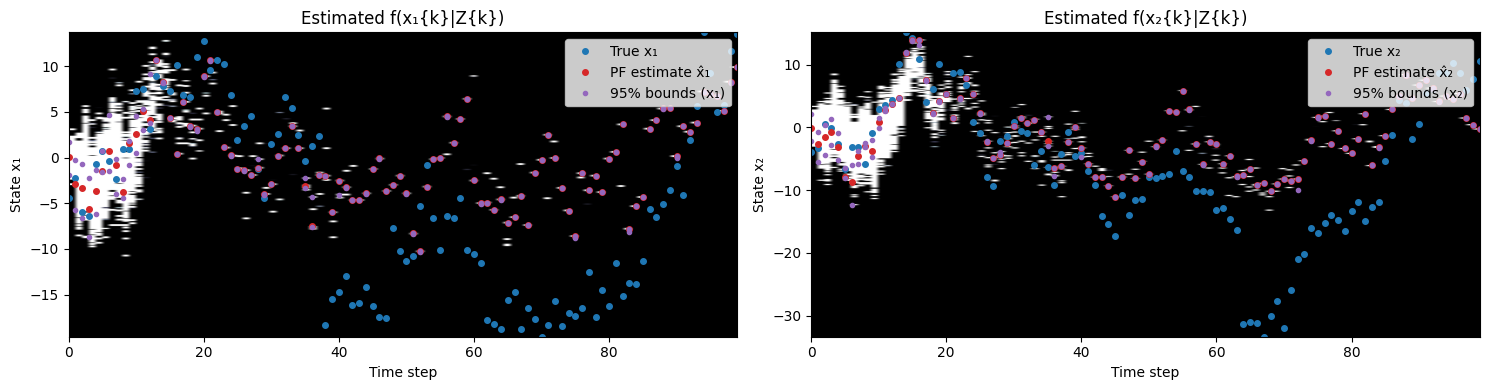

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Colormaps of SIS-estimated marginals f(x_1{k}|Z{k}) and f(x_2{k}|Z{k})
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# --- Left: x_1 ---
extent1 = [0, nIter - 1, xGrid[0], xGrid[-1]]
img1 = axs[0].imshow(estPDF_x1, aspect='auto', origin='lower', extent=extent1, cmap='bone')

# Match contrast similar to original (use 95th percentile)
vmax1 = np.percentile(estPDF_x1, 95)
img1.set_clim(0, vmax1)

# Overlay true x1 and PF estimate
axs[0].plot(time_idx, xk[:, 0], '.', markersize=8, color='C0', label='True x₁')
axs[0].plot(time_idx, xhatstore_pf[:, 0], '.', color='C3', markersize=8, label='PF estimate x̂₁')

# Overlay 95% confidence bounds
axs[0].plot(time_idx, xHiBndPart_x1, '.', color='C4', markersize=6, label='95% bounds (x₁)')
axs[0].plot(time_idx, xLowBndPart_x1, '.', color='C4', markersize=6)

axs[0].set_xlabel('Time step')
axs[0].set_ylabel('State x₁')
axs[0].set_title('Estimated f(x₁{k}|Z{k})')
axs[0].set_xlim(0, nIter - 1)
axs[0].legend(loc='upper right')

# --- Right: x_2 ---
extent2 = [0, nIter - 1, xGrid2[0], xGrid2[-1]]
img2 = axs[1].imshow(estPDF_x2, aspect='auto', origin='lower', extent=extent2, cmap='bone')

vmax2 = np.percentile(estPDF_x2, 95)
img2.set_clim(0, vmax2)

axs[1].plot(time_idx, xk[:, 1], '.', markersize=8, color='C0', label='True x₂')
axs[1].plot(time_idx, xhatstore_pf[:, 1], '.', color='C3', markersize=8, label='PF estimate x̂₂')

axs[1].plot(time_idx, xHiBndPart_x2, '.', color='C4', markersize=6, label='95% bounds (x₂)')
axs[1].plot(time_idx, xLowBndPart_x2, '.', color='C4', markersize=6)

axs[1].set_xlabel('Time step')
axs[1].set_ylabel('State x₂')
axs[1].set_title('Estimated f(x₂{k}|Z{k})')
axs[1].set_xlim(0, nIter - 1)
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

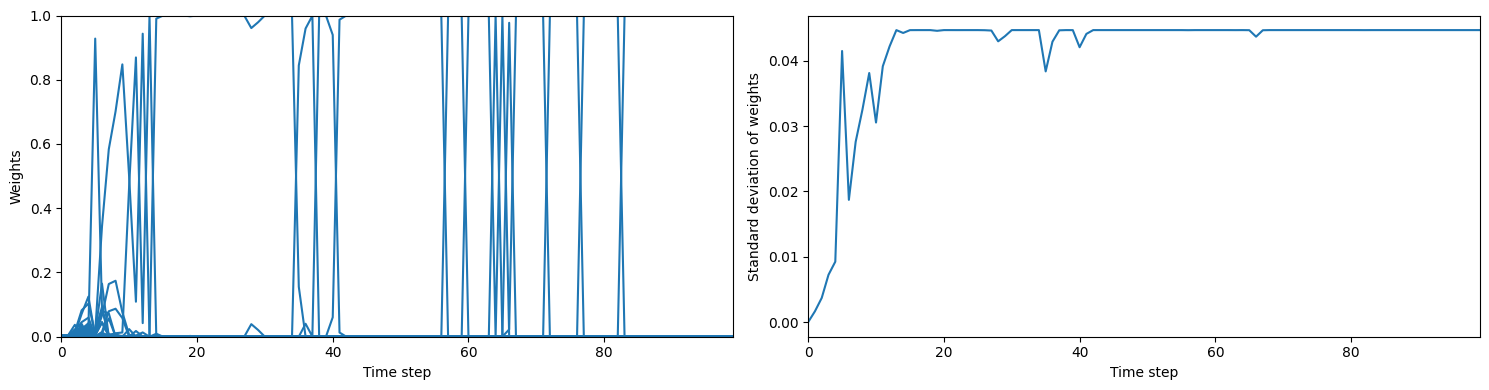

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Visualize particle weights
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# Plot the particle weights versus iteration (each particle trajectory of weights)
axs[0].plot(time_idx, wp.T, color='C0')
# axs[0].grid(True)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Weights')
# axs[0].set_title('Particle weights')
axs[0].set_xlim(0, nIter - 1)
axs[0].set_ylim(0, 1)

# Plot the standard deviation of the weights versus iteration
axs[1].plot(time_idx, np.std(wp, axis=0))
# axs[1].grid(True)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Standard deviation of weights')
# axs[1].set_title('Standard deviation of weights')
axs[1].set_xlim(0, nIter - 1)

plt.tight_layout()
plt.show()

END